# Oscar Demographics Analysis

* This file contains several graphs that highlight gender and race representation in the Oscars from data spanning the past 98 years (all 98 ceremonies!)
* These graphs highlight the sheer dominance that white men have held over the film and entertainment industry from its inception
* Racial diversity seems to have increased exponentially in the past 15 years, but the vast majority of winners and nominees are still white
* The proportion of female nominees has been steadily increasing over time

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
oscar_nominees = pd.read_csv("../data/oscars_demographics_comprehensive_2.csv")

<Figure size 640x480 with 0 Axes>

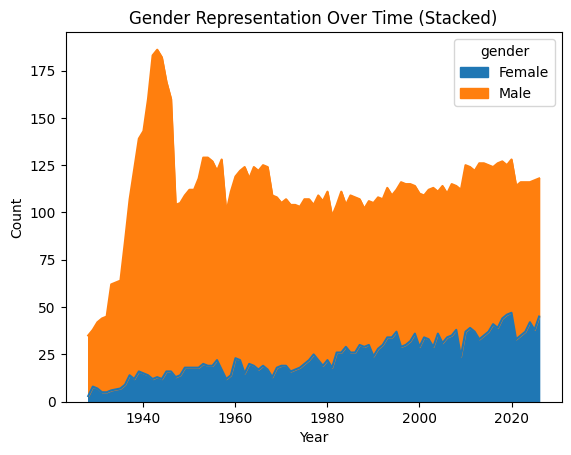

In [25]:
gender_year = oscar_nominees.groupby(['year_ceremony', 'gender']).size().unstack(fill_value=0)

plt.figure()
gender_year.plot.area()
plt.title("Gender Representation Over Time (Stacked)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

<Figure size 640x480 with 0 Axes>

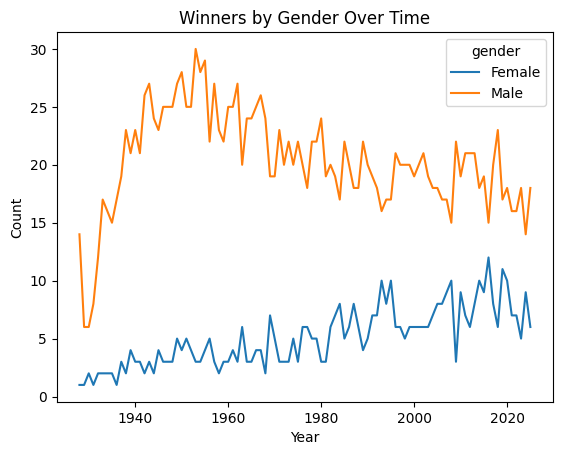

In [26]:
winners = oscar_nominees[oscar_nominees['winner'] == True]
winner_gender = winners.groupby(['year_ceremony', 'gender']).size().unstack(fill_value=0)

plt.figure()
winner_gender.plot()
plt.title("Winners by Gender Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

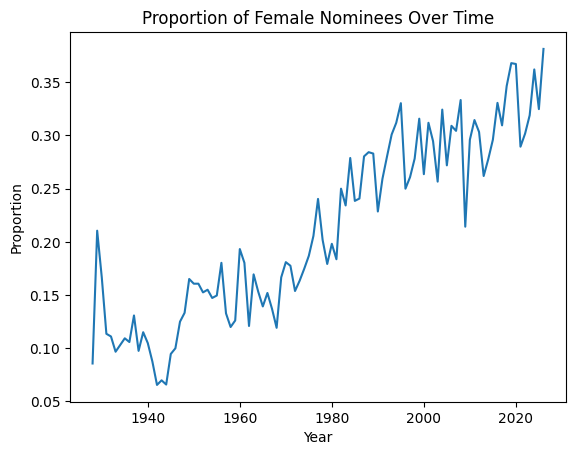

In [27]:
female_prop = gender_year.apply(lambda x: x / x.sum(), axis=1)

if 'Female' in female_prop.columns:
    plt.figure()
    female_prop['Female'].plot()
    plt.title("Proportion of Female Nominees Over Time")
    plt.xlabel("Year")
    plt.ylabel("Proportion")
    plt.show()

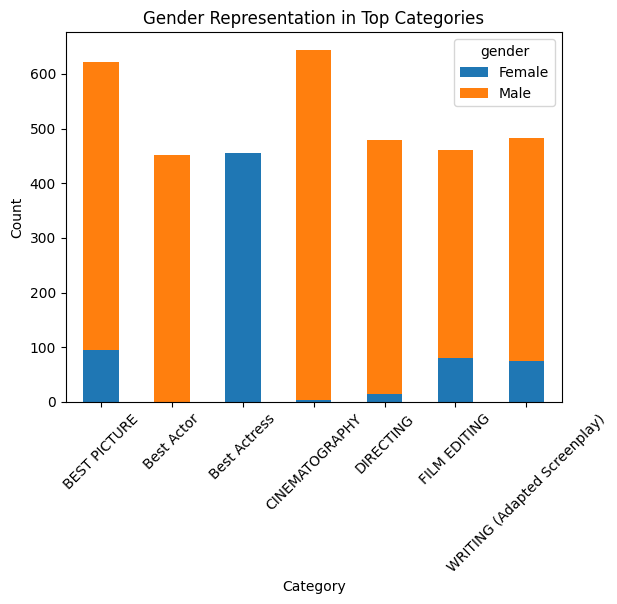

In [35]:
top_categories = oscar_nominees['Category'].value_counts().head(7).index

subset = oscar_nominees[oscar_nominees['Category'].isin(top_categories)]

cat_gender = subset.groupby(['Category', 'gender']).size().unstack(fill_value=0)

cat_gender.plot(kind='bar', stacked=True)
plt.title("Gender Representation in Top Categories")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

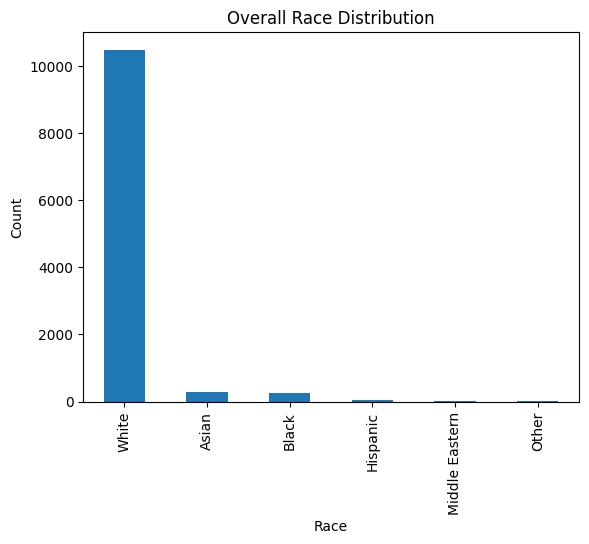

In [29]:
plt.figure()
oscar_nominees['Race'].value_counts().plot(kind='bar')
plt.title("Overall Race Distribution")
plt.ylabel("Count")
plt.show()

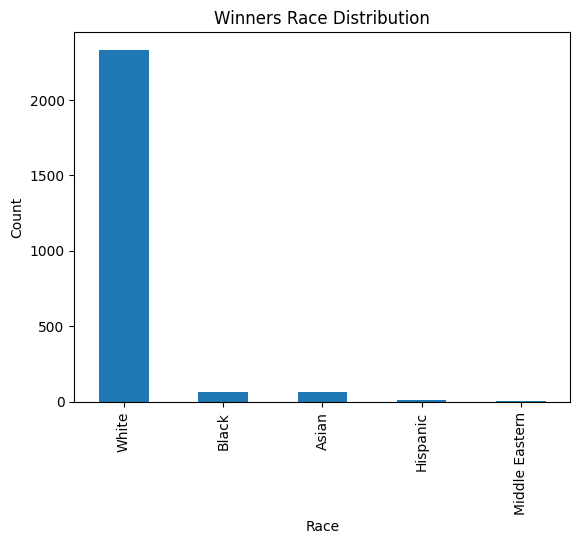

In [30]:
plt.figure()
winners['Race'].value_counts().plot(kind='bar')
plt.title("Winners Race Distribution")
plt.ylabel("Count")
plt.show()

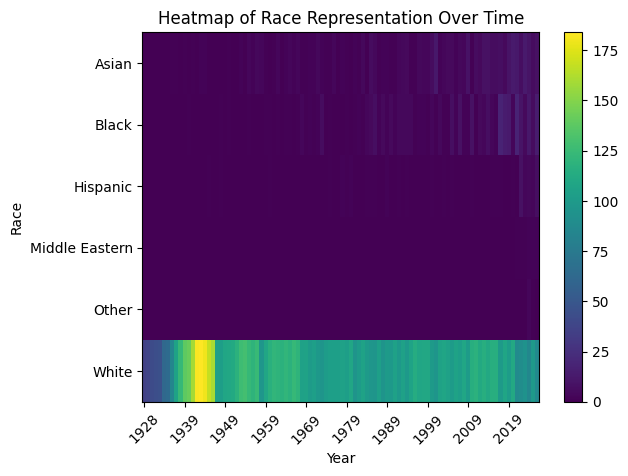

In [33]:
race_pivot = oscar_nominees.pivot_table(
    index='Race',
    columns='year_ceremony',
    aggfunc='size',
    fill_value=0
)

plt.figure()
plt.imshow(race_pivot, aspect='auto')
plt.colorbar()

plt.yticks(range(len(race_pivot.index)), race_pivot.index)
plt.xticks(range(0, len(race_pivot.columns), 10), race_pivot.columns[::10], rotation=45)

plt.title("Heatmap of Race Representation Over Time")
plt.xlabel("Year")
plt.ylabel("Race")
plt.show()

<Figure size 640x480 with 0 Axes>

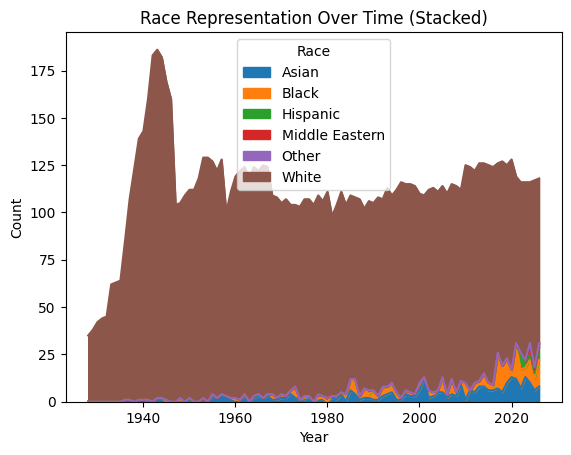

In [34]:
race_year = oscar_nominees.groupby(['year_ceremony', 'Race']).size().unstack(fill_value=0)

plt.figure()
race_year.plot.area()
plt.title("Race Representation Over Time (Stacked)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

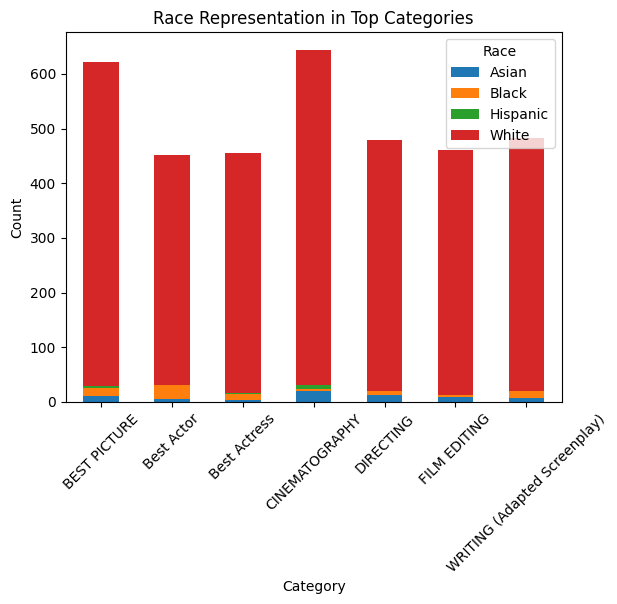

In [36]:
cat_race = subset.groupby(['Category', 'Race']).size().unstack(fill_value=0)

cat_race.plot(kind='bar', stacked=True)
plt.title("Race Representation in Top Categories")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# NEXT STEP: Direct comparison with census-reported demographic proportions?
# 21st century, classify the nominees as well, do full analysis -> compare with oscarssowhite before and after; top 100 movies in a year?